# Comparing Machine Learning Classification Methods

### Goal
Use **the same dataset and the same train/test split** to compare how different machine learning classifiers perform.

We will compare:

- Logistic Regression
- k-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Gaussian Naive Bayes
- Multilayer Perceptron (MLP)
- XGBoost

Dataset: **Breast Cancer Wisconsin** from `scikit-learn`.

The target is binary:

- `0` – malignant
- `1` – benign

> The important idea: **no single machine learning method is always the best**.  
> Performance depends on the dataset, preprocessing, hyperparameters, and evaluation metric.

In [14]:
# If needed, uncomment this line:
# !pip install numpy pandas matplotlib scikit-learn xgboost

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# In machine learning, random_state is a seed value used by algorithms that
# contain stochastic (random) steps. A fixed seed makes repeated runs reproducible.
# The value 42 has no special mathematical meaning; it is simply a common convention.
RANDOM_STATE = 42

## 1. Load the dataset

The dataset contains numerical measurements computed from digitized images of breast masses.

For this exercise, we treat it simply as a **binary classification dataset**.

In [15]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("Classes:", dict(enumerate(data.target_names)))
print()
print("Class counts:")
print(y.value_counts().sort_index())

X.head()

X shape: (569, 30)
Classes: {0: np.str_('malignant'), 1: np.str_('benign')}

Class counts:
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Use exactly the same train/test split for every classifier

This is essential for a fair comparison.

`stratify=y` keeps approximately the same class proportions in the training and test sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 398
Test samples: 171


## 3. Define the models

Some algorithms are sensitive to feature scale, so they are placed inside a pipeline with `StandardScaler`.

Tree-based methods, including Random Forest and XGBoost with tree boosters, generally do not require feature scaling.

For every algorithm, the code first gives a short **HOW IT WORKS** explanation and then explicitly shows the **main pedagogically relevant hyperparameters**: parameters that change model complexity, regularization, the prediction mechanism, or learning behaviour. Pure implementation options such as `verbose`, memory/cache settings, and parallel-processing controls are intentionally left at their defaults.

In [17]:
# Define all classifiers in one dictionary.
# Pipelines are used when a model benefits from feature standardization.
#
# StandardScaler():
#   transforms each feature approximately to mean = 0 and standard deviation = 1.
#   This is especially important for distance- or scale-sensitive methods
#   such as Logistic Regression, KNN, SVM, and MLP.

models = {

    # ------------------------------------------------------------
    # 1. LOGISTIC REGRESSION
    # HOW IT WORKS:
    # Learns a linear combination of the input features and maps it through
    # the logistic function to estimate the probability of a binary class.
    # The final class is obtained by applying a decision threshold.
    # ------------------------------------------------------------
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,                       # Inverse regularization strength.
                                         # Smaller C -> stronger regularization;
                                         # larger C -> weaker regularization.

            l1_ratio=0.0,                # Regularization mixture in current scikit-learn:
                                         # 0.0 -> L2, 1.0 -> L1, values in between -> Elastic Net.

            solver="lbfgs",             # Numerical optimization algorithm.
                                         # "lbfgs" is a strong default for many small/medium datasets.

            fit_intercept=True,          # Learn an intercept (bias) term.

            class_weight=None,           # Optional class weighting.
                                         # "balanced" increases the weight of minority classes.

            max_iter=2000                # Maximum number of optimization iterations.
                                         # Increase if the optimizer does not converge.
        ))
    ]),


    # ------------------------------------------------------------
    # 2. k-NEAREST NEIGHBORS (KNN)
    # HOW IT WORKS:
    # Does not learn an explicit global model. For a new sample, it finds
    # the k closest training samples and predicts from their class votes.
    # ------------------------------------------------------------
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5,               # Number of nearest training samples (k).
                                         # Small k -> flexible/noise-sensitive;
                                         # large k -> smoother decision boundary.

            weights="uniform",          # How neighbors vote:
                                         # "uniform" -> equal vote;
                                         # "distance" -> closer neighbors count more.

            metric="minkowski",         # Distance metric used to find neighbors.

            p=2                          # Minkowski power parameter:
                                         # p=1 -> Manhattan distance;
                                         # p=2 -> Euclidean distance.
        ))
    ]),


    # ------------------------------------------------------------
    # 3. SUPPORT VECTOR MACHINE (SVM)
    # HOW IT WORKS:
    # Finds a decision boundary with the largest possible margin between
    # classes. The RBF kernel allows a nonlinear boundary by measuring
    # similarity between samples in an implicit higher-dimensional space.
    # ------------------------------------------------------------
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,                       # Regularization parameter.
                                         # Larger C -> stronger fit to training data;
                                         # smaller C -> wider margin / stronger regularization.

            kernel="rbf",               # Radial Basis Function kernel allows
                                         # nonlinear decision boundaries.

            gamma="scale",              # RBF kernel coefficient.
                                         # Larger gamma -> each sample has more local influence;
                                         # smaller gamma -> smoother decision boundary.

            class_weight=None            # Optional class weighting for imbalanced data.
                                         # ROC AUC below uses decision_function(), so
                                         # probability=True is not required.
        ))
    ]),


    # ------------------------------------------------------------
    # 4. DECISION TREE
    # HOW IT WORKS:
    # Recursively splits the feature space into increasingly homogeneous
    # regions using simple if/then rules. A terminal leaf assigns the class
    # predicted for samples that follow that path through the tree.
    # ------------------------------------------------------------
    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",               # Function used to measure split quality.
                                         # Common alternatives: "entropy", "log_loss".

        splitter="best",                # How a split is selected at each node.
                                         # "best" chooses the best split; "random" samples one.

        max_depth=None,                  # Maximum depth of the tree.
                                         # None -> tree may keep growing until other
                                         # stopping rules are reached. Deep trees can overfit.

        min_samples_split=2,             # Minimum samples required to split an internal node.
                                         # Larger values make the tree more conservative.

        min_samples_leaf=1,              # Minimum samples required in each terminal leaf.
                                         # Larger values smooth the decision boundary.

        max_features=None,               # Number of features considered when searching a split.
                                         # None -> all features are considered.

        max_leaf_nodes=None,             # Maximum number of terminal leaves.
                                         # None -> no explicit leaf-count limit.

        min_impurity_decrease=0.0,       # Minimum impurity reduction required for a split.
                                         # Larger values suppress weak splits.

        ccp_alpha=0.0,                   # Cost-complexity pruning strength.
                                         # Larger values prune the tree more aggressively.

        class_weight=None,               # Optional class weighting; "balanced" is available.

        random_state=RANDOM_STATE        # Makes random choices in tree construction reproducible.
    ),


    # ------------------------------------------------------------
    # 5. RANDOM FOREST
    # HOW IT WORKS:
    # Trains many Decision Trees on bootstrap samples and random subsets of
    # features. Their votes are aggregated, reducing the variance and
    # instability of a single Decision Tree.
    # ------------------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=300,                # Number of Decision Trees in the forest.
                                         # More trees usually improve stability but cost time.

        criterion="gini",               # Split-quality measure used by individual trees.

        max_depth=None,                  # Maximum depth of each tree.
                                         # Restricting depth can reduce overfitting.

        min_samples_split=2,             # Minimum samples required to split a node.

        min_samples_leaf=1,              # Minimum samples required in a leaf.

        max_features="sqrt",            # Features randomly considered at each split.
                                         # "sqrt" is the usual classification default and
                                         # is an important source of diversity among trees.

        bootstrap=True,                  # Train each tree on a bootstrap sample.

        max_samples=None,                # Bootstrap sample size.
                                         # None -> each tree samples n training observations
                                         # with replacement when bootstrap=True.

        oob_score=False,                 # If True, use out-of-bag samples to estimate performance.

        ccp_alpha=0.0,                   # Cost-complexity pruning applied to individual trees.

        class_weight=None,               # Optional class weighting for imbalanced classes.

        random_state=RANDOM_STATE        # Reproducible bootstrap / feature randomness.
    ),


    # ------------------------------------------------------------
    # 6. GAUSSIAN NAIVE BAYES
    # HOW IT WORKS:
    # Applies Bayes' theorem and assumes that features are conditionally
    # independent within each class. Each feature is modeled with a Gaussian
    # distribution, and class probabilities are combined for prediction.
    # ------------------------------------------------------------
    "Gaussian Naive Bayes": GaussianNB(
        priors=None,                     # Prior probabilities of the classes.
                                         # None -> estimated from the training data.

        var_smoothing=1e-9               # Small value added to variances for numerical stability.
                                         # It can also affect model smoothness in practice.
    ),


    # ------------------------------------------------------------
    # 7. MULTILAYER PERCEPTRON (MLP)
    # HOW IT WORKS:
    # A feed-forward neural network passes information through one or more
    # hidden layers. The network learns weights by backpropagation so that
    # its predicted class probabilities minimize a loss function.
    # ------------------------------------------------------------
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(50,),    # Number of neurons in each hidden layer.
                                         # (50,) -> one hidden layer with 50 neurons.

            activation="relu",          # Hidden-layer activation function.

            solver="adam",              # Optimization algorithm used to update weights.

            alpha=0.0001,                # L2 regularization strength on network weights.

            batch_size="auto",          # Mini-batch size used by stochastic optimizers.

            learning_rate="constant",   # Learning-rate schedule.

            learning_rate_init=0.001,    # Initial learning rate for Adam / SGD.

            max_iter=2000,               # Maximum number of training iterations.

            shuffle=True,                # Shuffle training samples between iterations.

            early_stopping=False,        # If True, reserve validation data and stop when
                                         # validation performance no longer improves.

            validation_fraction=0.10,    # Fraction used for validation when
                                         # early_stopping=True.

            n_iter_no_change=10,         # Iterations without sufficient improvement
                                         # before stopping (when the stopping rule applies).

            random_state=RANDOM_STATE    # Reproducible weight initialization and shuffling.
        ))
    ]),


    # ------------------------------------------------------------
    # 8. XGBOOST CLASSIFIER
    # HOW IT WORKS:
    # Builds Decision Trees sequentially rather than independently. Each new
    # tree is trained to correct errors made by the current ensemble using
    # gradient boosting, and all tree contributions are combined.
    # ------------------------------------------------------------
    "XGBoost": XGBClassifier(
        booster="gbtree",               # Use tree-based gradient boosting.

        n_estimators=200,                # Number of boosting rounds / sequential trees.

        learning_rate=0.05,              # Contribution of each newly added tree.
                                         # Smaller values usually require more trees.

        max_depth=3,                     # Maximum depth of each base tree.
                                         # Deeper trees model more complex interactions.

        min_child_weight=1,              # Minimum child weight required to create a split.
                                         # Larger values make the model more conservative.

        gamma=0.0,                       # Minimum loss reduction required for a new split.
                                         # Larger values suppress weak splits.

        subsample=1.0,                   # Fraction of training samples used per tree.
                                         # Values below 1 introduce row subsampling.

        colsample_bytree=1.0,            # Fraction of features used to build each tree.

        reg_alpha=0.0,                   # L1 regularization on leaf weights.

        reg_lambda=1.0,                  # L2 regularization on leaf weights.

        scale_pos_weight=1.0,            # Relative weight of the positive class.
                                         # Useful for class imbalance when adjusted.

        objective="binary:logistic",    # Binary classification objective.

        eval_metric="logloss",          # Metric used internally to evaluate training loss.

        random_state=RANDOM_STATE        # Reproducible stochastic components.
    )
}

print("Number of classifiers:", len(models))

Number of classifiers: 8


## 4. Train and evaluate all classifiers

We calculate several metrics because **accuracy alone does not tell the whole story**.

- **Accuracy** – proportion of all correctly classified samples
- **Balanced accuracy** – average recall across classes
- **Precision** – how many predicted positives were correct
- **Recall** – how many actual positives were detected
- **F1-score** – balance between precision and recall
- **ROC AUC** – ranking/separation ability across classification thresholds

In [18]:
results = []
trained_models = {}

for name, model in models.items():
    start = time.perf_counter()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elapsed = time.perf_counter() - start

    # Probability / decision score for ROC AUC.
    # SVC does not need probability=True because decision_function() is valid for ROC AUC.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_score),
        "Training + prediction time (s)": elapsed
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(
    by="Balanced Accuracy",
    ascending=False
).reset_index(drop=True)

results_df.round(3)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Training + prediction time (s)
0,Logistic Regression,0.988,0.988,0.991,0.991,0.991,0.998,0.018
1,SVM (RBF),0.977,0.975,0.981,0.981,0.981,0.998,0.039
2,MLP,0.971,0.973,0.990,0.963,0.976,0.997,1.190
3,KNN,0.959,0.945,0.939,1.000,0.968,0.983,0.011
4,XGBoost,0.947,0.942,0.954,0.963,0.958,0.995,0.696
5,Gaussian Naive Bayes,0.947,0.936,0.938,0.981,0.959,0.990,0.006
6,Random Forest,0.942,0.934,0.945,0.963,0.954,0.992,2.156
7,Decision Tree,0.918,0.913,0.935,0.935,0.935,0.913,0.017


## 5. Visual comparison

Notice that the ranking can change depending on which metric you use.

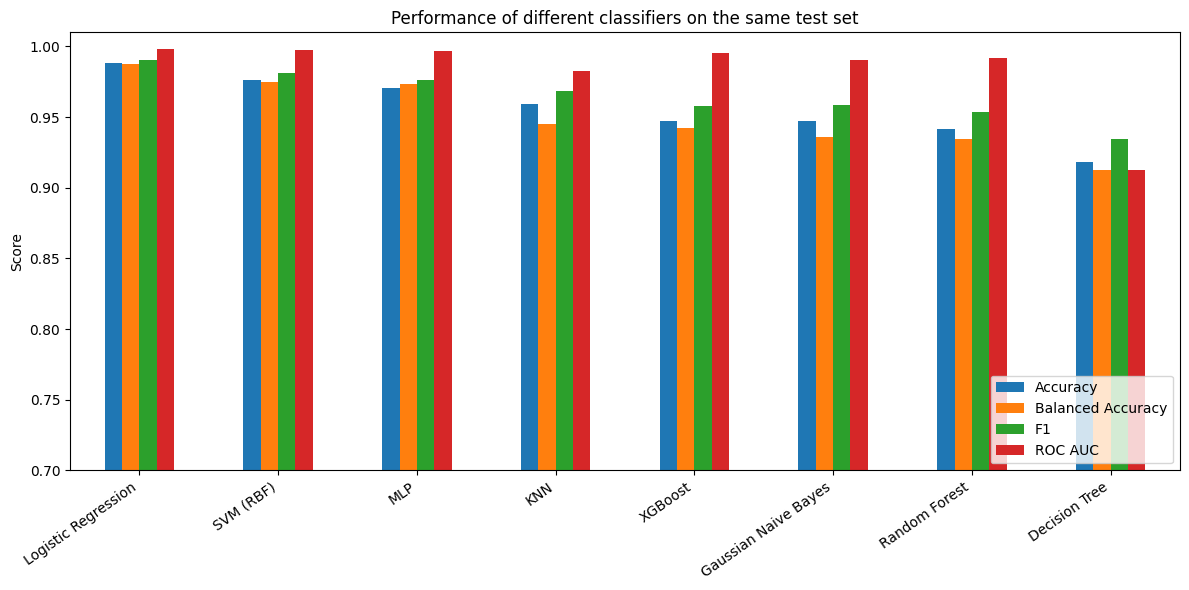

In [19]:
plot_df = results_df.set_index("Model")[["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]]

ax = plot_df.plot(kind="bar", figsize=(12, 6), ylim=(0.70, 1.01))
ax.set_title("Performance of different classifiers on the same test set")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. Confusion matrices

A confusion matrix shows **what kind of errors** each classifier makes.

This can be more informative than one summary number.

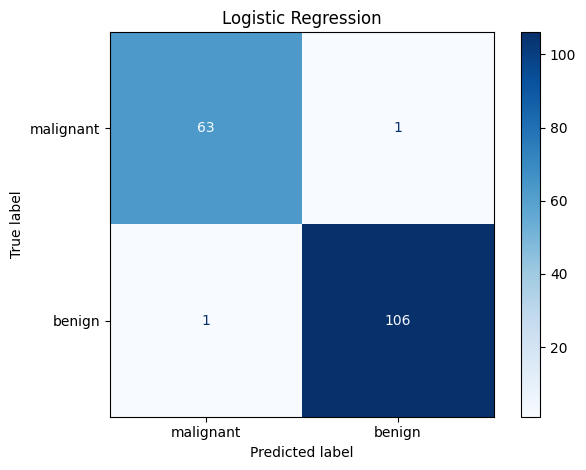

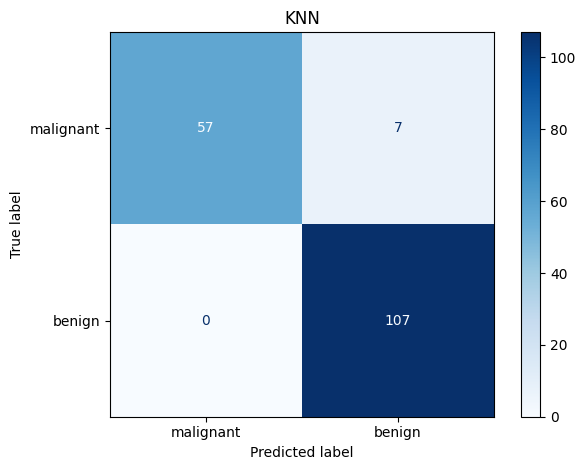

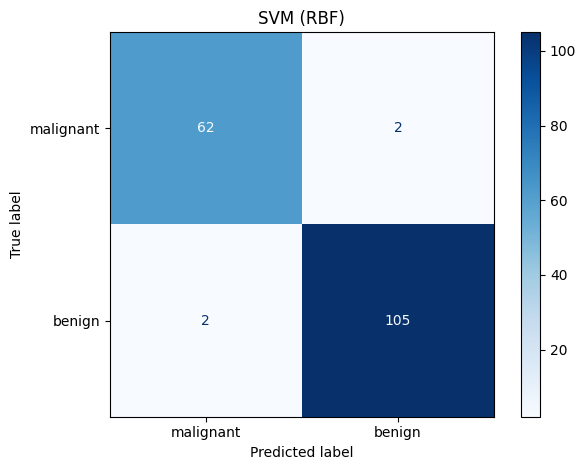

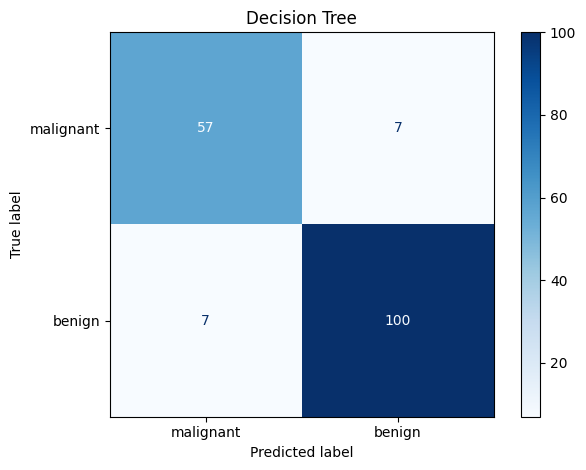

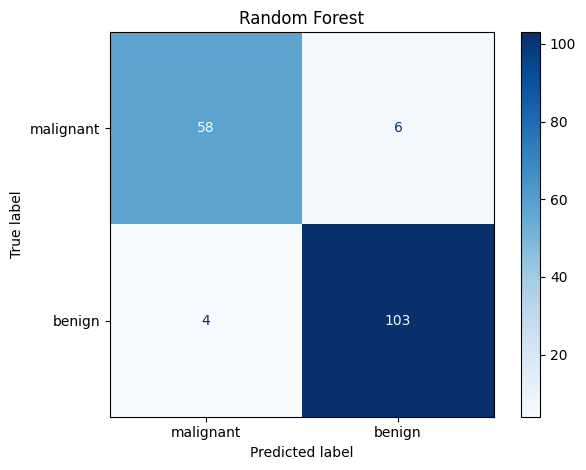

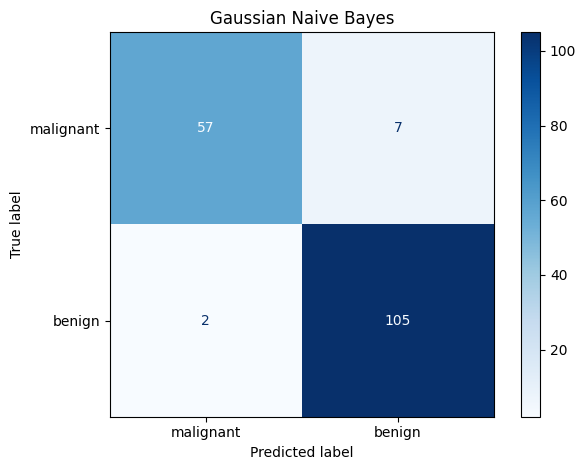

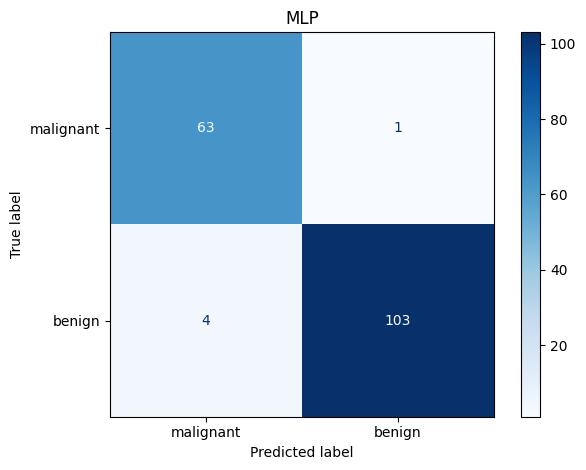

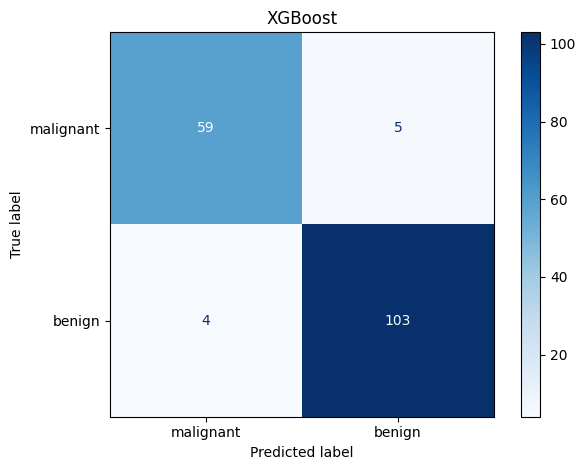

In [20]:
for name, model in trained_models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=data.target_names,
        cmap="Blues"
    )
    plt.title(name)
    plt.tight_layout()
    plt.show()

## 7. ROC curves

ROC curves compare classifier performance over many possible decision thresholds.

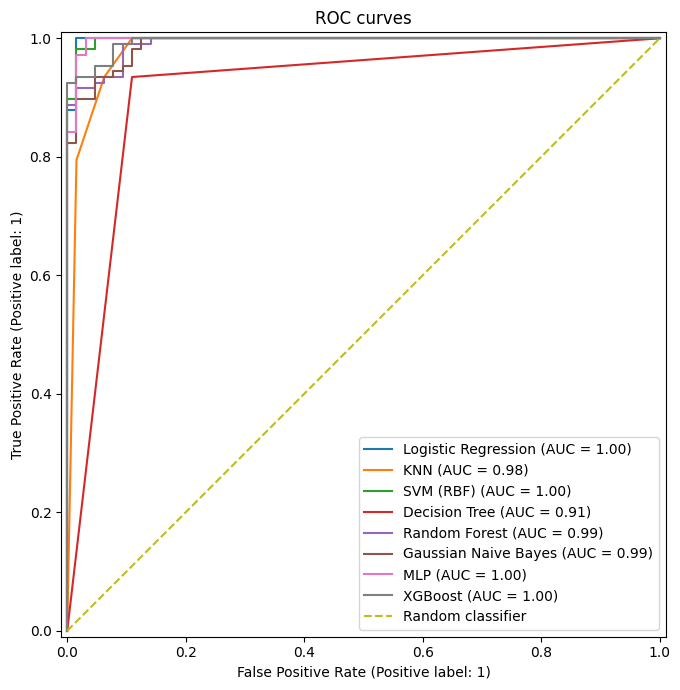

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
ax.set_title("ROC curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Which classifier is the best?

Sort the table by different metrics.

You may find that a model that is best by one metric is not necessarily best by another.

In [22]:
for metric in ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]:
    best_row = results_df.loc[results_df[metric].idxmax()]
    print(f"{metric:18s}: {best_row['Model']} ({best_row[metric]:.3f})")

Accuracy          : Logistic Regression (0.988)
Balanced Accuracy : Logistic Regression (0.988)
F1                : Logistic Regression (0.991)
ROC AUC           : Logistic Regression (0.998)


# Discussion questions for students

1. Why do different machine learning algorithms achieve different results on the same dataset?
2. Why do KNN, SVM, Logistic Regression, and MLP use `StandardScaler`, while Decision Tree and Random Forest do not?
3. Is the classifier with the highest **accuracy** automatically the best model?
4. Which error is more important in a medical classification problem: false positive or false negative?
5. Which Decision Tree parameters directly control overfitting?
6. Why does Random Forest randomly restrict the features considered at each split?
7. What is the difference between `C` and `gamma` in an RBF SVM?
8. How do `n_neighbors` and `weights` change KNN behaviour?
9. What happens if you change `RANDOM_STATE`?
10. Would the same classifier still be the best on another dataset?

## 9. Student experiment

Try changing **one parameter at a time**, rerun the evaluation, and compare the metrics.

```python
# KNN: model flexibility and voting rule
KNeighborsClassifier(n_neighbors=1, weights="uniform")
KNeighborsClassifier(n_neighbors=15, weights="distance")

# SVM: regularization and RBF kernel width
SVC(C=0.1, gamma="scale")
SVC(C=100, gamma=0.01)

# Decision Tree: two important controls of tree complexity
DecisionTreeClassifier(max_depth=2, min_samples_leaf=1)
DecisionTreeClassifier(max_depth=None, min_samples_leaf=10)

# Random Forest: number of trees and random feature subset size
RandomForestClassifier(n_estimators=50, max_features="sqrt")
RandomForestClassifier(n_estimators=500, max_features=None)

# Logistic Regression: regularization strength
LogisticRegression(C=0.01, max_iter=2000)
LogisticRegression(C=100, max_iter=2000)

# Gaussian Naive Bayes: variance smoothing
GaussianNB(var_smoothing=1e-11)
GaussianNB(var_smoothing=1e-7)

# MLP: architecture and regularization
MLPClassifier(hidden_layer_sizes=(20,), alpha=0.0001, max_iter=2000)
MLPClassifier(hidden_layer_sizes=(100, 50), alpha=0.01, max_iter=2000)

# XGBoost: boosting rate, number of trees, and tree complexity
XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=2)
XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=5)
```

### Main conclusion

> Machine learning performance is determined not only by the dataset, but also by the **choice of algorithm, preprocessing, hyperparameters, data split, and evaluation metric**.

# Part II — Comparing Regression Methods

In classification, the target is a **class label**.

In regression, the target is a **continuous numerical value**.

Here we use the same idea as before:

- one dataset;
- one train/test split;
- several different regression algorithms;
- the same evaluation metrics for all algorithms.

We will compare:

- Linear Regression
- Ridge Regression
- k-Nearest Neighbors Regressor
- Support Vector Regression (SVR)
- Decision Tree Regressor
- Random Forest Regressor
- Multilayer Perceptron Regressor (MLP)
- XGBoost Regressor

Dataset: **Diabetes dataset** from `scikit-learn`.

The target is a continuous measure of disease progression one year after baseline.

In [23]:
# Regression-specific imports
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Load the regression dataset

The input contains several numerical patient-related variables.

The target is **continuous**, so this is a regression problem.

In [24]:
reg_data = load_diabetes(scaled=False)  # Load the diabetes dataset without scaling features

X_reg = pd.DataFrame(reg_data.data, columns=reg_data.feature_names)
y_reg = pd.Series(reg_data.target, name="disease_progression")

print("X shape:", X_reg.shape)
print("Target range:", y_reg.min(), "to", y_reg.max())
print()
print(y_reg.describe())

X_reg.head()

X shape: (442, 10)
Target range: 25.0 to 346.0

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: disease_progression, dtype: float64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


## 2. Use the same train/test split for every regression model

Again, this is essential for a fair comparison.

All models will be trained on exactly the same training observations and tested on exactly the same test observations.

In [25]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,              # 30% of observations are reserved for testing.
    random_state=RANDOM_STATE    # Makes the split reproducible.
)

print("Training samples:", len(X_reg_train))
print("Test samples:", len(X_reg_test))

Training samples: 309
Test samples: 133


## 3. Define the regression models

As in classification, some methods are sensitive to feature scale.

Therefore, `StandardScaler()` is used for:

- Ridge Regression
- KNN Regression
- Support Vector Regression
- MLP Regression

Ordinary Linear Regression generally does **not** require feature scaling: rescaling predictors changes the numerical coefficients but not the fitted OLS predictions. Scaling is important for Ridge because its L2 penalty depends on coefficient magnitude.

Tree-based methods, including Random Forest and XGBoost with tree boosters, generally do not require feature scaling.

For every algorithm, the code first gives a short **HOW IT WORKS** explanation and then shows the **main parameters that affect model behaviour or complexity**, while implementation-only settings are left at their defaults.

In [26]:
regression_models = {

    # ------------------------------------------------------------
    # 1. LINEAR REGRESSION
    # HOW IT WORKS:
    # Fits a linear equation that minimizes the sum of squared residuals
    # between observed and predicted continuous target values.
    # ------------------------------------------------------------
    "Linear Regression": LinearRegression(
        fit_intercept=True,              # Learn an intercept (bias) term.
                                         # False forces the model through the origin.

        positive=False                   # If True, coefficients are constrained to be >= 0.
                                         # Usually False unless such a constraint is justified.
    ),


    # ------------------------------------------------------------
    # 2. RIDGE REGRESSION
    # HOW IT WORKS:
    # Fits a linear regression model while adding an L2 penalty on large
    # coefficients. This shrinks coefficients and can reduce overfitting,
    # especially when predictors are correlated or numerous.
    # ------------------------------------------------------------
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(
            alpha=1.0,                    # Strength of L2 regularization.
                                          # Larger alpha -> stronger coefficient shrinkage;
                                          # alpha -> 0 approaches ordinary Linear Regression.

            fit_intercept=True,           # Learn an intercept term.

            solver="auto",               # Algorithm used to solve the optimization problem.
                                          # "auto" chooses a suitable solver automatically.

            tol=1e-4,                     # Convergence tolerance for iterative solvers.

            max_iter=None                 # Maximum iterations for iterative solvers.
                                          # None -> solver-specific default.
        ))
    ]),


    # ------------------------------------------------------------
    # 3. k-NEAREST NEIGHBORS REGRESSOR
    # HOW IT WORKS:
    # Predicts a continuous value from the target values of the k nearest
    # training observations, usually by taking an average or a
    # distance-weighted average.
    # ------------------------------------------------------------
    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=5,                # Number of nearest observations used in prediction.
                                          # Small k -> flexible/noise-sensitive;
                                          # large k -> smoother predictions.

            weights="uniform",           # "uniform" -> equal contribution;
                                          # "distance" -> closer neighbors contribute more.

            metric="minkowski",          # Distance metric used to identify neighbors.

            p=2                           # Minkowski power: p=1 Manhattan, p=2 Euclidean.
        ))
    ]),


    # ------------------------------------------------------------
    # 4. SUPPORT VECTOR REGRESSION (SVR)
    # HOW IT WORKS:
    # Fits a function while trying to keep prediction errors inside an
    # epsilon-wide insensitive tube. The RBF kernel allows nonlinear
    # relationships while C controls the penalty for larger errors.
    # ------------------------------------------------------------
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            C=1.0,                        # Penalty for prediction errors.
                                          # Larger C -> fit training data more closely;
                                          # smaller C -> stronger regularization.

            kernel="rbf",                # Nonlinear Radial Basis Function kernel.

            gamma="scale",               # RBF kernel coefficient.
                                          # Larger gamma -> more local/complex function;
                                          # smaller gamma -> smoother function.

            epsilon=0.1,                  # Width of the epsilon-insensitive tube.
                                          # Errors inside this tube are not penalized.

            tol=1e-3                      # Optimization stopping tolerance.
        ))
    ]),


    # ------------------------------------------------------------
    # 5. DECISION TREE REGRESSOR
    # HOW IT WORKS:
    # Recursively splits the feature space into regions that contain similar
    # target values. Each terminal leaf predicts a constant value, typically
    # based on the training targets that reached that leaf.
    # ------------------------------------------------------------
    "Decision Tree Regressor": DecisionTreeRegressor(
        criterion="squared_error",       # Function used to measure split quality.
                                          # Other choices include "friedman_mse",
                                          # "absolute_error", and "poisson".

        splitter="best",                 # "best" chooses the best split;
                                          # "random" introduces additional randomness.

        max_depth=None,                   # Maximum depth of the tree.
                                          # None can produce a very deep, overfitted tree.

        min_samples_split=2,              # Minimum samples required to split a node.

        min_samples_leaf=1,               # Minimum samples required in a terminal leaf.
                                          # Larger values usually smooth predictions.

        max_features=None,                # Features considered while searching for a split.
                                          # None -> all features are considered.

        max_leaf_nodes=None,              # Maximum number of terminal leaves.

        min_impurity_decrease=0.0,        # Minimum impurity reduction required for a split.

        ccp_alpha=0.0,                    # Cost-complexity pruning strength.
                                          # Larger values produce more pruning.

        random_state=RANDOM_STATE         # Makes random choices reproducible.
    ),


    # ------------------------------------------------------------
    # 6. RANDOM FOREST REGRESSOR
    # HOW IT WORKS:
    # Trains many regression trees on bootstrap samples and random feature
    # subsets, then averages their predictions. Averaging reduces the
    # variance and instability of a single regression tree.
    # ------------------------------------------------------------
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,                 # Number of Decision Trees in the forest.

        criterion="squared_error",       # Split-quality measure for individual trees.

        max_depth=None,                   # Maximum depth of each tree.

        min_samples_split=2,              # Minimum samples required to split a node.

        min_samples_leaf=1,               # Minimum samples required in a leaf.

        max_features=1.0,                 # Fraction/number of features considered per split.
                                          # 1.0 means all features for the regressor default.
                                          # Lower values increase randomness among trees.

        bootstrap=True,                   # Build trees from bootstrap samples.

        max_samples=None,                 # Bootstrap sample size when bootstrap=True.
                                          # None -> sample n training observations with replacement.

        oob_score=False,                  # If True, estimate prediction performance from
                                          # out-of-bag observations.

        ccp_alpha=0.0,                    # Cost-complexity pruning for individual trees.

        random_state=RANDOM_STATE         # Reproducible bootstrap / feature randomness.
    ),


    # ------------------------------------------------------------
    # 7. MULTILAYER PERCEPTRON REGRESSOR (MLP)
    # HOW IT WORKS:
    # A feed-forward neural network combines nonlinear transformations across
    # hidden layers and learns its weights by backpropagation to minimize a
    # continuous prediction loss such as squared error.
    # ------------------------------------------------------------
    "MLP Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            #loss="squared_error",         # Regression loss minimized during training.

            hidden_layer_sizes=(50,),     # Hidden-layer architecture.
                                          # (50,) -> one hidden layer with 50 neurons.

            activation="relu",           # Hidden-layer activation function.

            solver="adam",               # Optimization algorithm.

            alpha=0.0001,                 # L2 regularization strength on network weights.

            batch_size="auto",           # Mini-batch size for stochastic optimization.

            learning_rate="constant",    # Learning-rate schedule.

            learning_rate_init=0.001,     # Initial learning rate for Adam / SGD.

            max_iter=2000,                # Maximum training iterations.

            shuffle=True,                 # Shuffle observations between iterations.

            early_stopping=True,          # Reserve validation data and stop when validation
                                          # performance no longer improves.

            validation_fraction=0.10,     # Fraction of training data used for validation.

            n_iter_no_change=20,          # Validation iterations without sufficient
                                          # improvement before stopping.

            random_state=RANDOM_STATE     # Reproducible initialization and shuffling.
        ))
    ]),


    # ------------------------------------------------------------
    # 8. XGBOOST REGRESSOR
    # HOW IT WORKS:
    # Builds regression trees sequentially with gradient boosting. Each new
    # tree focuses on reducing the residual errors of the current ensemble,
    # and the weighted contributions of all trees form the final prediction.
    # ------------------------------------------------------------
    "XGBoost Regressor": XGBRegressor(
        booster="gbtree",                # Use tree-based gradient boosting.

        n_estimators=200,                 # Number of boosting rounds / sequential trees.

        learning_rate=0.05,               # Contribution of each newly added tree.
                                          # Smaller values usually require more trees.

        max_depth=3,                      # Maximum depth of each base tree.

        min_child_weight=1,               # Minimum child weight required for a split.
                                          # Larger values make the model more conservative.

        gamma=0.0,                        # Minimum loss reduction required for a new split.

        subsample=1.0,                    # Fraction of training samples used per tree.

        colsample_bytree=1.0,             # Fraction of features used to build each tree.

        reg_alpha=0.0,                    # L1 regularization on leaf weights.

        reg_lambda=1.0,                   # L2 regularization on leaf weights.

        objective="reg:squarederror",    # Standard squared-error regression objective.

        eval_metric="rmse",              # Internal evaluation metric.

        random_state=RANDOM_STATE         # Reproducible stochastic components.
    )
}

print("Number of regression models:", len(regression_models))

Number of regression models: 8


## 4. Train and evaluate all regression models

For regression we use different metrics than for classification:

- **MAE (Mean Absolute Error)**  
  Average absolute difference between predicted and true values.  
  **Lower is better.**

- **RMSE (Root Mean Squared Error)**  
  Similar to MAE, but large errors receive more weight.  
  **Lower is better.**

- **R² (Coefficient of Determination)**  
  Indicates how much of the variability in the target is explained by the model.  
  **Higher is better.**

Typical interpretation of R²:

- `R² = 1` → perfect predictions
- `R² = 0` → approximately no better than predicting the mean target
- `R² < 0` → worse than predicting the mean target

In [27]:
reg_results = []
trained_regression_models = {}

for name, model in regression_models.items():
    start = time.perf_counter()

    model.fit(X_reg_train, y_reg_train)
    y_reg_pred = model.predict(X_reg_test)

    elapsed = time.perf_counter() - start

    mae = mean_absolute_error(y_reg_test, y_reg_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
    r2 = r2_score(y_reg_test, y_reg_pred)

    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Training + prediction time (s)": elapsed
    })

    trained_regression_models[name] = model

reg_results_df = pd.DataFrame(reg_results).sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

reg_results_df.round(3)

,Model,MAE,RMSE,R²,Training + prediction time (s)
0,Random Forest Regressor,42.396,53.027,0.479,1.085
1,Ridge Regression,41.878,53.104,0.478,0.008
2,Linear Regression,41.919,53.120,0.477,0.025
3,XGBoost Regressor,43.023,54.155,0.457,0.070
4,KNN Regressor,44.805,57.252,0.393,0.010
5,MLP Regressor,45.901,57.976,0.377,1.918
6,SVR (RBF),56.434,67.292,0.161,0.015
7,Decision Tree Regressor,59.835,75.410,-0.053,0.012


## 5. Visual comparison of regression performance

Remember:

- lower **MAE** is better;
- lower **RMSE** is better;
- higher **R²** is better.

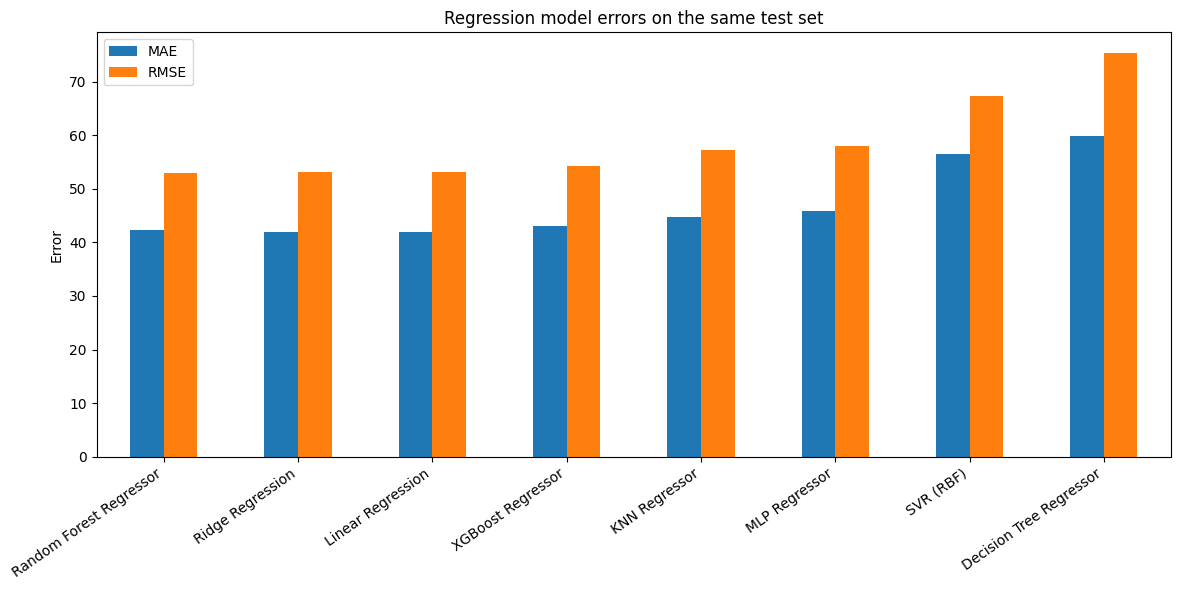

In [28]:
ax = reg_results_df.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_title("Regression model errors on the same test set")
ax.set_ylabel("Error")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

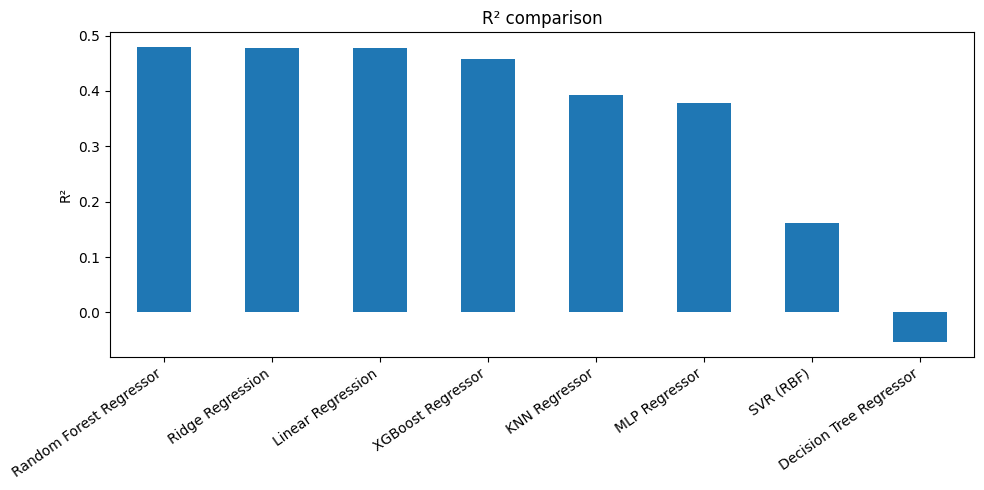

In [29]:
ax = reg_results_df.set_index("Model")[["R²"]].plot(
    kind="bar",
    figsize=(10, 5),
    legend=False
)
ax.set_title("R² comparison")
ax.set_ylabel("R²")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. Actual vs predicted values

A good regression model should produce points close to the diagonal line:

**predicted value ≈ actual value**

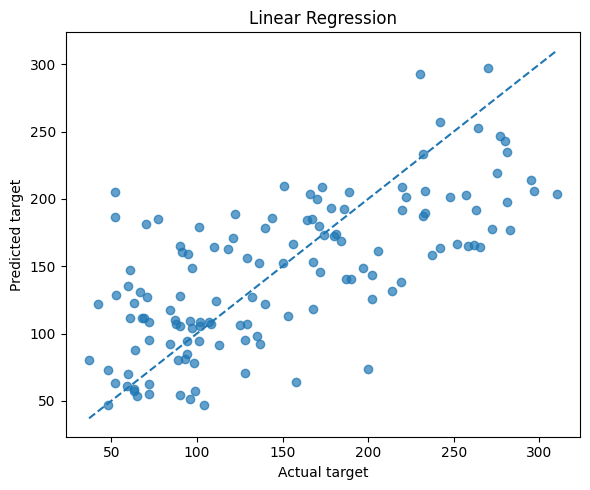

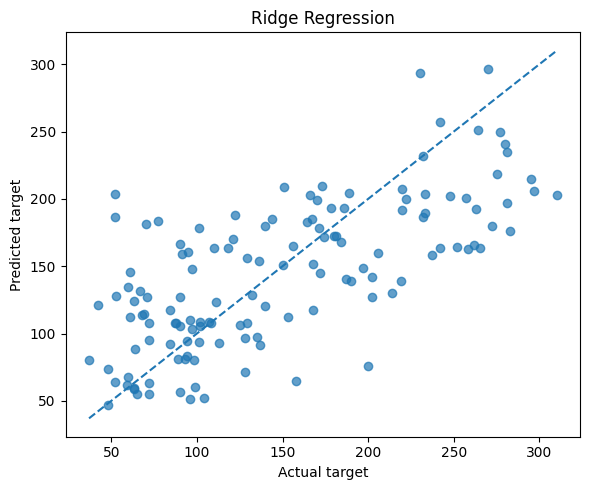

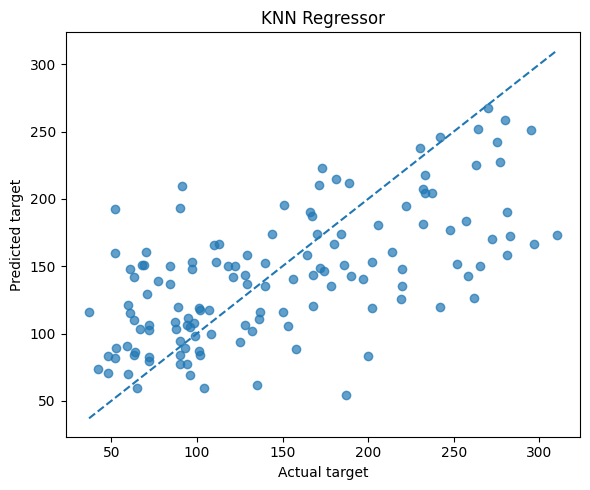

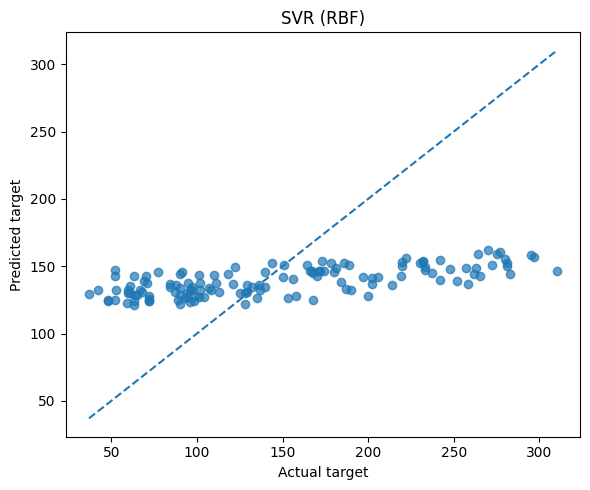

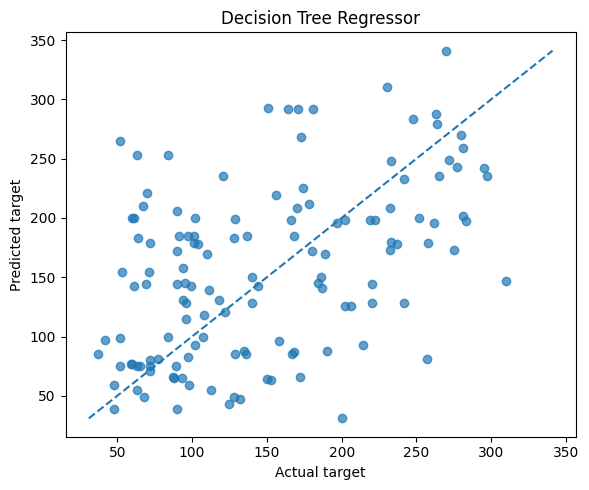

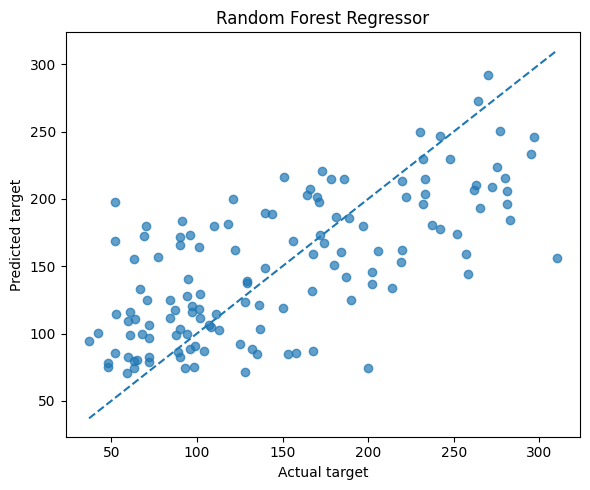

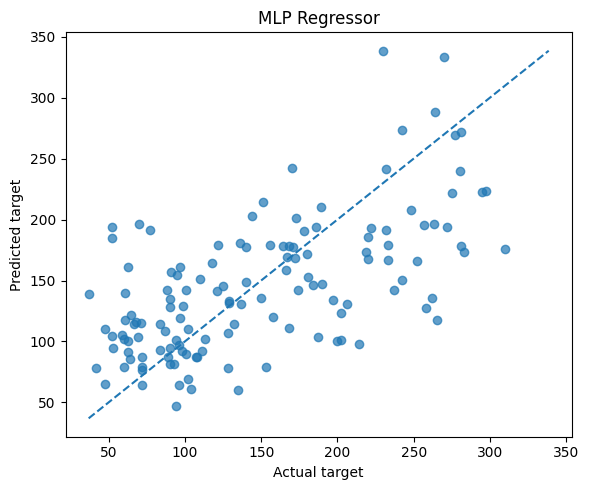

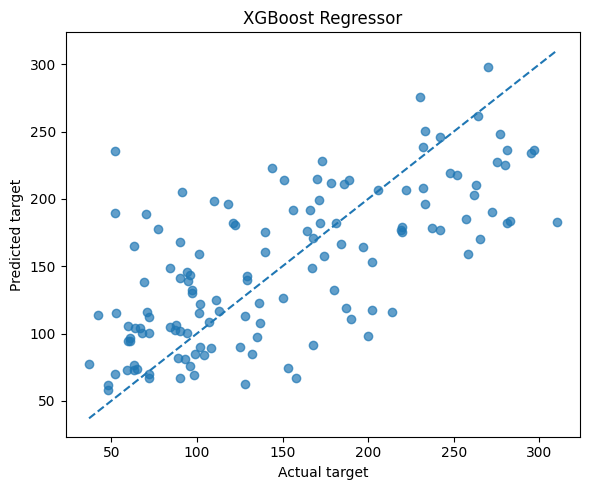

In [30]:
for name, model in trained_regression_models.items():
    y_pred = model.predict(X_reg_test)

    plt.figure(figsize=(6, 5))
    plt.scatter(y_reg_test, y_pred, alpha=0.7)

    low = min(y_reg_test.min(), y_pred.min())
    high = max(y_reg_test.max(), y_pred.max())

    plt.plot([low, high], [low, high], linestyle="--")

    plt.xlabel("Actual target")
    plt.ylabel("Predicted target")
    plt.title(name)
    plt.tight_layout()
    plt.show()

## 7. Residual plots

A residual is:

**residual = actual value − predicted value**

Residuals close to zero indicate small prediction errors.

A useful residual plot can reveal whether the model systematically overpredicts or underpredicts certain observations.

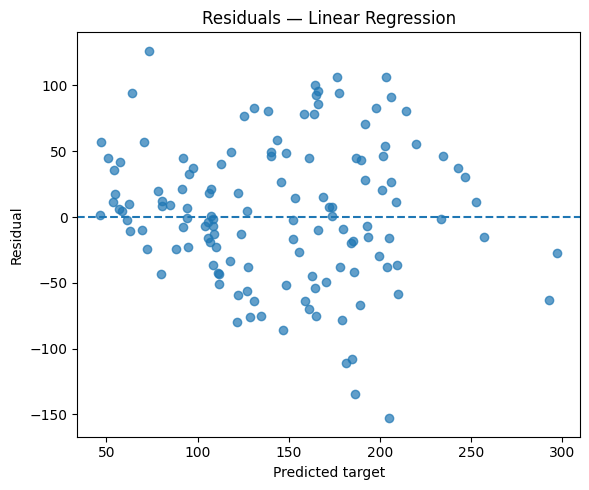

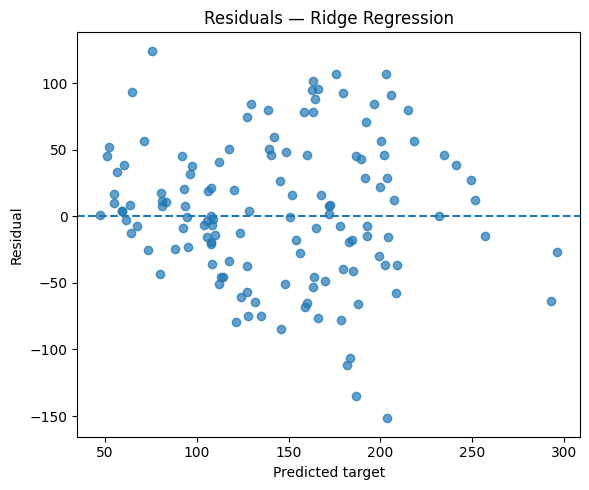

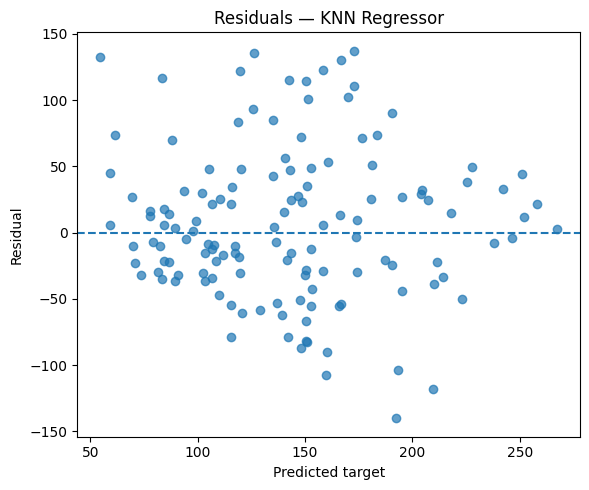

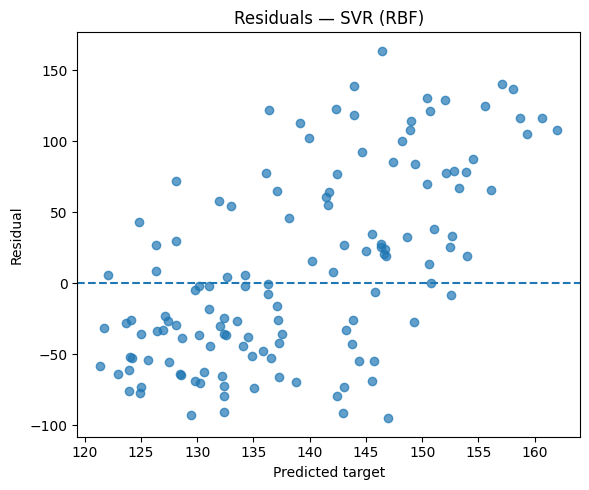

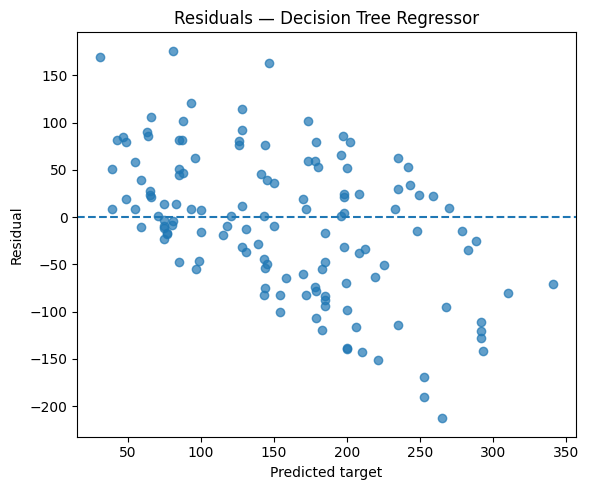

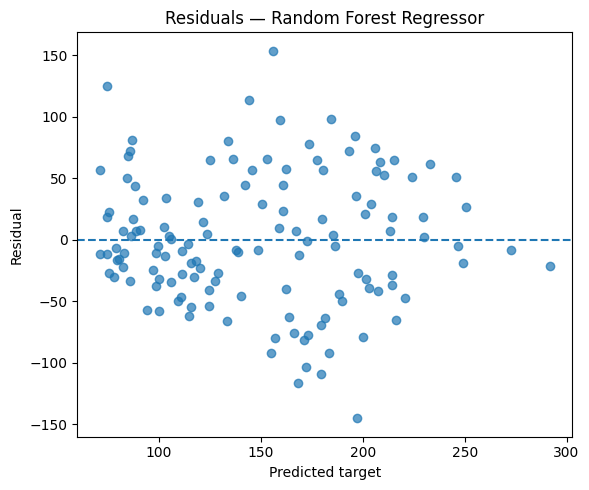

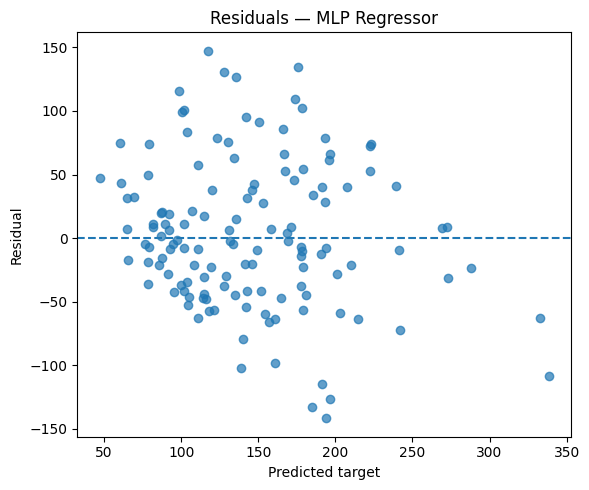

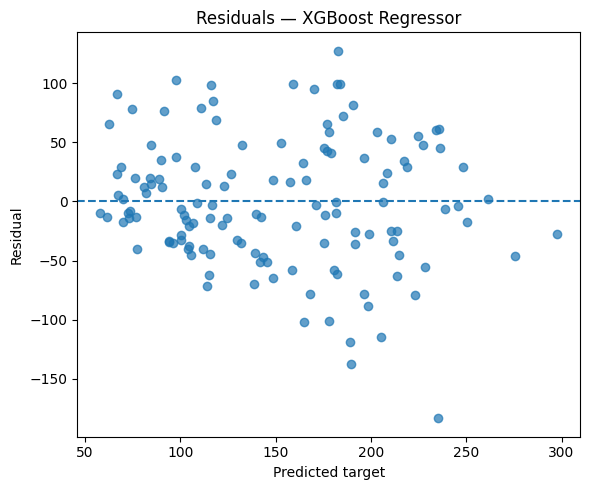

In [31]:
for name, model in trained_regression_models.items():
    y_pred = model.predict(X_reg_test)
    residuals = y_reg_test - y_pred

    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, linestyle="--")

    plt.xlabel("Predicted target")
    plt.ylabel("Residual")
    plt.title(f"Residuals — {name}")
    plt.tight_layout()
    plt.show()

## 8. Which regression model is best?

Unlike classification, there is no Accuracy score here.

The ranking can also depend on the chosen regression metric.

In [32]:
best_mae = reg_results_df.loc[reg_results_df["MAE"].idxmin()]
best_rmse = reg_results_df.loc[reg_results_df["RMSE"].idxmin()]
best_r2 = reg_results_df.loc[reg_results_df["R²"].idxmax()]

print(f"Best MAE : {best_mae['Model']} ({best_mae['MAE']:.3f})")
print(f"Best RMSE: {best_rmse['Model']} ({best_rmse['RMSE']:.3f})")
print(f"Best R²  : {best_r2['Model']} ({best_r2['R²']:.3f})")

Best MAE : Ridge Regression (41.878)
Best RMSE: Random Forest Regressor (53.027)
Best R²  : Random Forest Regressor (0.479)


# Classification vs Regression

| | Classification | Regression |
|---|---|---|
| **Target** | Class / category | Continuous number |
| **Example** | Disease / no disease | Blood pressure |
| **Typical methods** | Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Naive Bayes | Linear Regression, Ridge, KNN Regressor, SVR, Decision Tree Regressor, Random Forest Regressor |
| **Typical metrics** | Accuracy, Precision, Recall, F1, ROC AUC | MAE, RMSE, R² |
| **Output** | Class or class probability | Numerical value |

The important point is that **many ML ideas appear in both classification and regression**, but the prediction target and evaluation metrics are different.

# Discussion questions

1. Why is Accuracy not appropriate for regression?
2. What is the difference between MAE and RMSE?
3. Why does RMSE penalize large errors more strongly than MAE?
4. What does an R² value close to 1 mean?
5. What does a negative R² value mean?
6. Why is scaling important for KNN and SVR?
7. Which parameters can be used to reduce overfitting in a Decision Tree Regressor?
8. Why can Random Forest Regression be more stable than one Decision Tree?
9. How do `C`, `gamma`, and `epsilon` play different roles in SVR?
10. Why might Linear Regression outperform a more complex nonlinear method on some datasets?

## Student experiment

Try changing **one parameter at a time**:

```python
# Ridge: L2 regularization strength
Ridge(alpha=0.01)
Ridge(alpha=100)

# KNN: neighborhood size and neighbor weighting
KNeighborsRegressor(n_neighbors=1, weights="uniform")
KNeighborsRegressor(n_neighbors=15, weights="distance")

# SVR: regularization, kernel width, and epsilon-insensitive tube
SVR(C=0.1, gamma="scale", epsilon=0.1)
SVR(C=100, gamma=0.01, epsilon=1.0)

# Decision Tree: depth and minimum leaf size
DecisionTreeRegressor(max_depth=2, min_samples_leaf=1)
DecisionTreeRegressor(max_depth=None, min_samples_leaf=10)

# Random Forest: forest size and random feature subset
RandomForestRegressor(n_estimators=50, max_features=1.0)
RandomForestRegressor(n_estimators=500, max_features=0.5)

# MLP Regressor: architecture, regularization, and learning rate
MLPRegressor(hidden_layer_sizes=(20,), alpha=0.0001, learning_rate_init=0.001, max_iter=2000)
MLPRegressor(hidden_layer_sizes=(100, 50), alpha=0.01, learning_rate_init=0.0003, max_iter=2000)

# XGBoost Regressor: boosting rate, number of trees, and tree complexity
XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2)
XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=5)
```

Then rerun the evaluation and observe how **MAE, RMSE, and R²** change.

### Main conclusion

> Different regression algorithms can give substantially different predictions on the same dataset because they make different assumptions about the relationship between input features and the continuous target.